# Chatbot With MCP Server

In [1]:
%pip install langchain-mcp-adapters mcp pywin32 -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [7]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
# os.environ['CONTEXT7_API_KEY'] = os.getenv('CONTEXT7_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### MCP Server 연동
- `http` 원격지의 MCP Server를 web 방식 호출
- `stdio` MCP Client system에서 MCP Server구동하는 경우

In [ ]:
# MutiServerMCPClient로 MCP 서버 2개 연결 후 도구 목록 조회
from langchain_mcp_adapters.client import MultiServerMCPClient

CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')

# MCP 서버 설정 클라이언트
mcp_client = MultiServerMCPClient({
    # Langchain Docs MCP 서버
    "docs-langchain" : {
        "url" : "https://docs.langchain.com/mcp", # 엔드포인트
        "transport": 'http' # 전송방식
    },
    # Context7 MCP서버
    "context7" : {
        "url" : "https://mcp.context7.com/mcp", # 엔드포인트
        "headers" : { # 인증정보를 담은 헤더
            "CONTEXT7_API_KEY" : CONTEXT7_API_KEY
        },
        "transport" : 'http'
    }

})

# get_tools는 비동기 메서드이므로 await로 동작 처리
mcp_tools = await mcp_client.get_tools() # MCP 서버 Tool 목록 조회

mcp_tools

[StructuredTool(name='search_docs_by_lang_chain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages. If you need the full content of a specific page, use the query_docs_filesystem tool to `head` or `cat` the page path (append `.mdx` to the path returned from search — e.g. `head -200 /api-reference/create-customer.mdx`).', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}}, 'required': ['query'], 'additionalProperties': False}, metadata={'title': None, 'readOnlyHint': True, 'destructiveHint': False, 'idempotentHint': True, 'openWorldHint': False}, handle_tool_error=<function _handle_mcp_tool_

In [9]:
from typing import TypedDict, Annotated, List       # 타입 힌트 도구
from langgraph.graph.message import add_messages    # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
# Tavily Search 도구 생성 및 검색
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    # messages 필드가 add_messages 규칙으로 누적 저장
    messages: Annotated[List, add_messages] 

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool] + mcp_tools
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 바인딩

# State의 messages 를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    # 누적된 메시지 리스트로 LLM 호출
    response = llm_with_tools.invoke(state['messages']) 
    # add_messages 규칙에 의해 기존 messages에 응답이 누적됨. 
    return {'messages': [response]}    

<class 'langgraph.graph.state.CompiledStateGraph'>


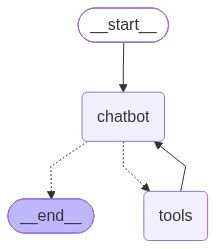

In [ ]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# State 스키마 기반 그래프 설계 객체 생성
builder = StateGraph(State) 
tool_node = ToolNode(tools)

# 시작 노드 -> chatbot 노드
builder.add_edge(START, 'chatbot') 

builder.add_node('chatbot', chatbot) # chatbot 노드
builder.add_node('tools', tool_node) # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools','chatbot')

graph = builder.compile() # 설계된 워크 플로우를 실행 가능한 그래프로 컴파일
print(type(graph)) # 그래프 타입 확인
graph # 그래프 객체

In [11]:
from pprint import pprint

user_query = '최근 삼성전자와 하이닉스 주가는 어떻게 돼?'

state = {'messages' : [('human', user_query)]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = graph.invoke(state) 
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 삼성전자와 하이닉스 주가는 어떻게 돼?', additional_kwargs={}, response_metadata={}, id='98baf32b-5f73-4722-b480-599063a554a1'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 3173, 'total_tokens': 3226, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrFNdNJX61M05ZIwmXVhbyHcZMXe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0650b-12ec-70d0-a043-ccb9a2e8faf6-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '삼성전자 하이닉스 최근 주가 현재가', 'topic': 'finance',

In [ ]:
from pprint import pprint

user_query = 'langchain 최신버전에서 새롭게 추가된 부분은?'

state = {'messages' : [('human', user_query)]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = await graph.ainvoke(state) 
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='langchain 최신버전에서 새롭게 추가된 부분은? langchain docs mcp 에서 검색해봐', additional_kwargs={}, response_metadata={}, id='5838778f-3347-4298-ab10-368e32aeb58b'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 3182, 'total_tokens': 3214, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2688, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrM8DMWfElYrRtUJm5MBeANw9zLV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06511-7bab-7ea0-882a-44b1c06190d3-0', tool_calls=[{'name': 'search_docs_by_lang_chain', 'args': {'que

In [ ]:
user_query = '웹 프레임워크 개발시 필요한 라이브러리가 뭐야?'

state = {'messages' : [('human', user_query)]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = await graph.ainvoke(state) 
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='웹 프레임워크 개발시 필요한 라이브러리가 뭐야?', additional_kwargs={}, response_metadata={}, id='903a93bb-5bc1-45db-9b0a-046537a93ee1'),
              AIMessage(content='웹 프레임워크를 개발할 때 필요한 라이브러리는 “무조건 정해진 세트”가 있다기보다, **프레임워크가 제공할 기능 범위**에 따라 달라집니다.  \n보통은 아래 범주로 나눠서 생각하면 됩니다.\n\n## 1) 필수에 가까운 기본 라이브러리\n- **HTTP 서버/라우팅**\n  - 요청을 받고 URL/메서드별로 처리\n  - 예: 라우터, 미들웨어 체인, 핸들러\n- **요청/응답 파서**\n  - JSON, form-data, query string, cookie 처리\n- **템플릿 엔진**(서버 렌더링이 있으면)\n  - HTML 생성\n- **검증(validation)**\n  - 입력값 타입/형식 검사\n- **환경 설정(config)**\n  - env 로딩, 설정 분리\n- **로깅(logging)**\n  - 요청 로그, 에러 로그, 구조화 로그\n- **에러 처리**\n  - 전역 에러 핸들링, 에러 클래스\n\n## 2) 자주 필요한 유틸성 라이브러리\n- **입력 sanitization / XSS 방지**\n- **CORS 처리**\n- **쿠키 / 세션**\n- **인증/인가**\n  - JWT, OAuth, session auth\n- **파일 업로드**\n- **캐싱**\n  - 메모리 캐시, Redis 연동\n- **Rate limit**\n- **압축(compression)**\n- **보안 헤더**\n  - CSP, HSTS 등\n- **국제화(i18n)**\n\n## 3) 개발 생산성용\n- **핫 리로드 / 파일 감시**\n- **테스트 프레임워크**\n  - 단위 테스트, 통합 테스트\n- **Moc

In [17]:
user_query = '여름 - 가을로 가는 중간 지점에 먹을만한 음식은?'

state = {'messages' : [('human', user_query)]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = await graph.ainvoke(state) 
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='여름 - 가을로 가는 중간 지점에 먹을만한 음식은?', additional_kwargs={}, response_metadata={}, id='32a72725-a318-489d-bace-ba4403270e39'),
              AIMessage(content='여름에서 가을로 넘어가는 **환절기**엔, 너무 차갑지도 너무 무겁지도 않은 음식이 잘 맞아요. 추천드리면:\n\n### 먹기 좋은 음식\n- **닭곰탕 / 삼계탕**: 기운 보충에 좋고, 아직 더위가 남아 있을 때도 부담이 덜해요.\n- **전어구이 / 전어회**: 가을 시작 느낌이 나는 대표 제철 음식.\n- **버섯 요리**: 표고, 느타리, 송이버섯 같은 향이 좋은 재료가 잘 어울려요.\n- **호박죽 / 단호박 스프**: 속을 편하게 해주고, 너무 차갑지 않아서 좋아요.\n- **국수류**: 냉면보다 **잔치국수, 온국수**처럼 따뜻한 메뉴가 무난해요.\n- **새우, 꽃게 요리**: 가을 초입에 해산물 맛이 좋아지기 시작해요.\n- **배, 사과**: 간식으로도 좋고 수분 보충에도 괜찮아요.\n\n### 분위기까지 챙기면\n- **구운 고구마**\n- **밤**\n- **도토리묵**\n- **가을 나물 반찬**\n\n원하시면 제가  \n1) **집밥용**, 2) **밖에서 먹기 좋은 메뉴**, 3) **제철 재료로만**  \n나눠서 더 구체적으로 추천해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 340, 'prompt_tokens': 3179, 'total_tokens': 3519, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_